# Sentinel_AI – Fraud Detection Model Explanation
## Understanding the data, model, and evaluation metrics

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve
from src.data import generate_fraud_data, preprocess_data
from src.features import engineer_features

%matplotlib inline

In [2]:
os.makedirs("images", exist_ok=True)

## 1. Load Data and Show Class Imbalance

Fraud rate: 13.32%


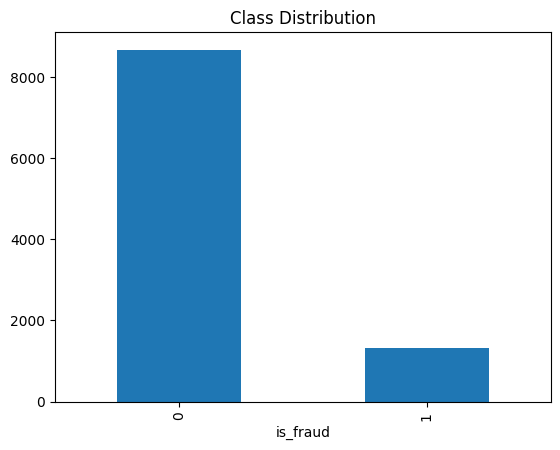

In [6]:
df = generate_fraud_data(10000)
print("Fraud rate: {:.2%}".format(df['is_fraud'].mean()))
df['is_fraud'].value_counts().plot(kind='bar', title='Class Distribution')
plt.savefig("images/class_distributions.png", bbox_inches='tight')
plt.show()

## 2. Visualize Feature Distributions

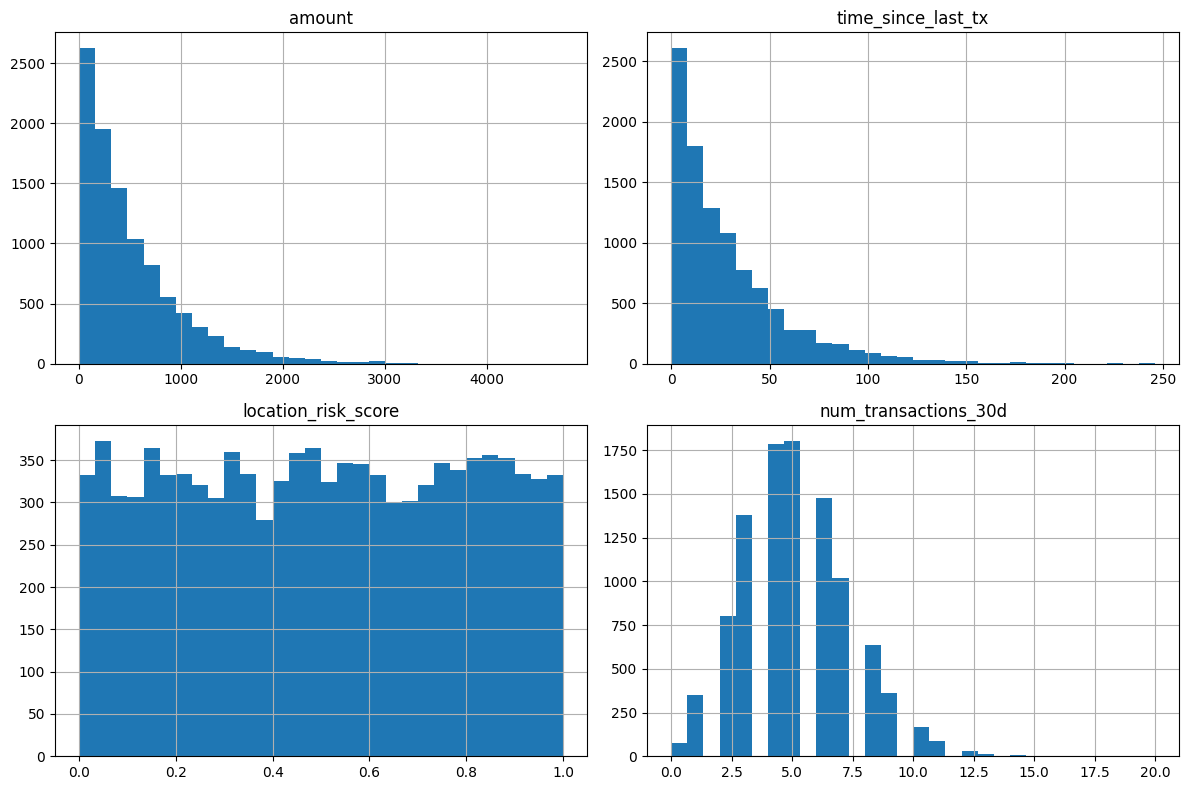

In [9]:
features = ['amount', 'time_since_last_tx', 'location_risk_score', 'num_transactions_30d']
df[features].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.savefig("images/feature_histograms.png", bbox_inches='tight')
plt.show()

## 3. Train a Simple RandomForest and Show Feature Importance

In [10]:
# Preprocess
X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Feature importance (original feature names)
feature_names = ['amount', 'time_since_last_tx', 'avg_transaction_amount_30d',
                 'num_transactions_30d', 'location_risk_score', 'card_type',
                 'is_foreign', 'hour_of_day', 'day_of_week']
importances = model.feature_importances_
pd.Series(importances, index=feature_names).sort_values(ascending=False).plot(kind='bar', title='Feature Importances')
plt.savefid("images/feature_importances.png", bbox_inches='tight')
plt.show()

ValueError: Length of values (10) does not match length of index (9)

## 4. Explain ROC‑AUC and Average Precision

ROC-AUC: 0.547
Average Precision: 0.161


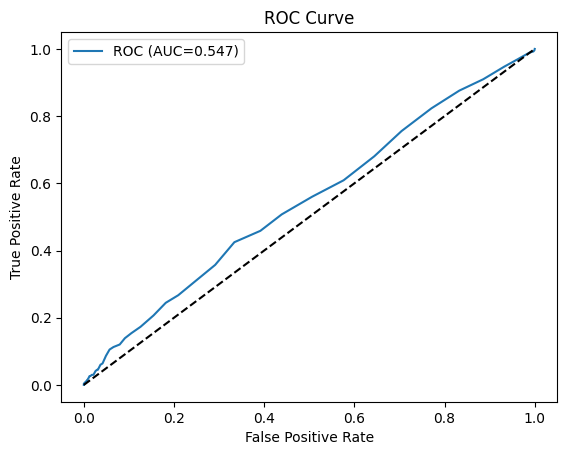

In [11]:
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")
print(f"Average Precision: {ap:.3f}")

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("images/roc_curve.png", bbox_inches='tight')
plt.show()

## 5. How to Use the Model for Predictions

In [ ]:
# Example: predict on first 5 test samples
sample = X_test[:5]
probs = model.predict_proba(sample)[:, 1]
print("Fraud probabilities:", probs)

# Choose threshold (e.g., 0.5)
threshold = 0.5
flags = (probs >= threshold).astype(int)
print("Flag as fraud:", flags)